# Метод 1 — CatBoost. Часть 1: данные и leak-safe фичи

In [ ]:
from __future__ import annotations
import sys
from pathlib import Path

ROOT = Path('/Users/ensamsanovich/auc_forecast')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUT_DIR = ROOT / 'outputs' / 'method_1_catboost'
OUT_DIR.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from core.config import TARGETS, set_seed
from core.runner import load_unified_data
from core.leak_safe_features import build_leak_safe_aggregates

set_seed()

#### Загрузка данных

In [2]:
data = load_unified_data()
split = data['split']

val = data['val']
ans = data['ans']

print(f"val:           {val.shape}")
print(f"ans:           {ans.shape}")
print(f"train_idx:     {len(split['train_idx'])} кампаний")
print(f"holdout_idx:   {len(split['holdout_idx'])} кампаний")
print(f"число фолдов:  {len(split['folds'])}")

val:           (1008, 6)
ans:           (1008, 3)
train_idx:     806 кампаний
holdout_idx:   202 кампаний
число фолдов:  5


In [3]:
fold_summary = pd.DataFrame(
    [(i, len(tr), len(va)) for i, (tr, va) in enumerate(split['folds'])],
    columns=['fold', 'n_train', 'n_val'],
)
fold_summary

,fold,n_train,n_val
0,0,644,162
1,1,645,161
2,2,645,161
3,3,645,161
4,4,645,161


#### Признаки 

In [4]:
X = build_leak_safe_aggregates(data['val'], data['user_index'], data['pub_index'])
y = data['ans'][list(TARGETS)].astype(float)

print(f"X: {X.shape}, признаков: {X.shape[1]}")
print(f"y: {y.shape}, цели: {list(TARGETS)}")
X.head()

X: (1008, 39), признаков: 39
y: (1008, 3), цели: ['at_least_one', 'at_least_two', 'at_least_three']


,cpm,audience_size,hour_start,hour_end,campaign_duration,num_publishers,hour_start_of_day,hour_end_of_day,coverage_morning,coverage_afternoon,...,pub_median_cpm,pub_std_cpm,pub_mean_age,pub_male_ratio,pub_imp_per_user,pub_premium_ratio,pub_high_volume_ratio,cpm_x_duration,cpm_x_audience,audience_known_ratio
0,220.0,1906,1058,1153,95,2,2,1,0.252632,0.252632,...,104.212498,418.667526,31.013830,0.402830,8.628101,1.000000,0.50,20900.0,419320.0,0.890871
1,312.0,1380,1295,1301,6,2,23,5,0.000000,0.000000,...,88.592499,543.627602,29.367885,0.663655,13.139861,1.000000,0.50,1872.0,430560.0,0.997826
2,70.0,888,1229,1249,20,6,5,1,0.300000,0.300000,...,88.744999,386.876807,28.903716,0.533237,20.141016,0.833333,0.50,1400.0,62160.0,0.902027
3,240.0,440,1295,1377,82,2,23,9,0.256098,0.219512,...,108.750000,334.540634,30.247096,0.612551,23.936595,1.000000,0.50,19680.0,105600.0,0.922727
4,262.0,1476,752,990,238,4,8,6,0.243697,0.252101,...,99.542500,411.514645,31.107511,0.556827,13.006651,1.000000,0.75,62356.0,386712.0,0.802846


In [5]:
feature_cols = list(X.columns)
print(f"Всего признаков: {len(feature_cols)}")
for i, name in enumerate(feature_cols):
    print(f"  {i + 1:02d}. {name}")

Всего признаков: 39
  01. cpm
  02. audience_size
  03. hour_start
  04. hour_end
  05. campaign_duration
  06. num_publishers
  07. hour_start_of_day
  08. hour_end_of_day
  09. coverage_morning
  10. coverage_afternoon
  11. coverage_evening
  12. coverage_night
  13. aud_n_known
  14. aud_mean_imp
  15. aud_median_imp
  16. aud_std_imp
  17. aud_mean_cpm
  18. aud_median_cpm
  19. aud_std_cpm
  20. aud_mean_pub_diversity
  21. aud_mean_hour
  22. aud_morning_ratio
  23. aud_afternoon_ratio
  24. aud_evening_ratio
  25. aud_night_ratio
  26. pub_n_known
  27. pub_mean_imp
  28. pub_mean_users
  29. pub_mean_cpm
  30. pub_median_cpm
  31. pub_std_cpm
  32. pub_mean_age
  33. pub_male_ratio
  34. pub_imp_per_user
  35. pub_premium_ratio
  36. pub_high_volume_ratio
  37. cpm_x_duration
  38. cpm_x_audience
  39. audience_known_ratio


#### Распределение таргетов по train/holdout

In [6]:
train_idx = split['train_idx']
holdout_idx = split['holdout_idx']

summary = pd.DataFrame({
    'target': list(TARGETS),
    'train_mean': [y.iloc[train_idx][t].mean() for t in TARGETS],
    'holdout_mean': [y.iloc[holdout_idx][t].mean() for t in TARGETS],
    'train_std': [y.iloc[train_idx][t].std() for t in TARGETS],
    'holdout_std': [y.iloc[holdout_idx][t].std() for t in TARGETS],
})
summary

,target,train_mean,holdout_mean,train_std,holdout_std
0,at_least_one,0.128044,0.065156,0.153123,0.099624
1,at_least_two,0.075870,0.025647,0.125137,0.069247
2,at_least_three,0.055554,0.013717,0.106819,0.045024


#### Временная ось кампаний

In [7]:
time_col_candidates = ['hour_start', 'start_hour', 'start_ts', 'campaign_start']
time_col = next((c for c in time_col_candidates if c in val.columns), None)

if time_col is None:
    print("Колонка времени не найдена, используем порядковый индекс кампании.")
    camp_time = pd.Series(np.arange(len(val)), name='order')
else:
    print(f"Используем колонку времени: {time_col}")
    camp_time = pd.Series(val[time_col].values).reset_index(drop=True)
    try:
        camp_time = pd.to_datetime(camp_time)
    except (ValueError, TypeError):
        pass

order = np.argsort(camp_time.values)
sorted_time = camp_time.iloc[order].reset_index(drop=True)
cum = np.arange(1, len(sorted_time) + 1)
print(f"Кампаний всего: {len(sorted_time)}")

Используем колонку времени: hour_start
Кампаний всего: 1008


#### Сдвигающаяся граница временного разбиения

In [8]:
n_total = len(sorted_time)
n_train = len(train_idx)

N_FRAMES = 20
start_cut = max(1, int(0.10 * n_total))
cut_positions = np.linspace(start_cut, n_train, N_FRAMES).astype(int)

is_datetime = np.issubdtype(np.asarray(sorted_time).dtype, np.datetime64)
x_axis = sorted_time.values

for step, cut in enumerate(cut_positions, start=1):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x_axis, cum, color='#1f77b4', linewidth=1.8, label='Кумулятивное число кампаний')
    ax.fill_between(x_axis[:cut], cum[:cut], color='#1f77b4', alpha=0.18, label='Train')
    ax.fill_between(x_axis[cut - 1:], cum[cut - 1:], color='#d62728', alpha=0.18, label='Holdout')
    ax.axvline(x_axis[cut - 1], color='black', linestyle='--', linewidth=1.4, label=f'Граница: {cut} кампаний')
    ax.set_xlabel('hour_start' if is_datetime else 'порядковый индекс кампании')
    ax.set_ylabel('кумулятивное число кампаний')
    ax.set_title(f'Временное разбиение: кадр {step}/{N_FRAMES} (граница = {cut})')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f'fig_split_step_{step:03d}.png', dpi=110)
    plt.close(fig)

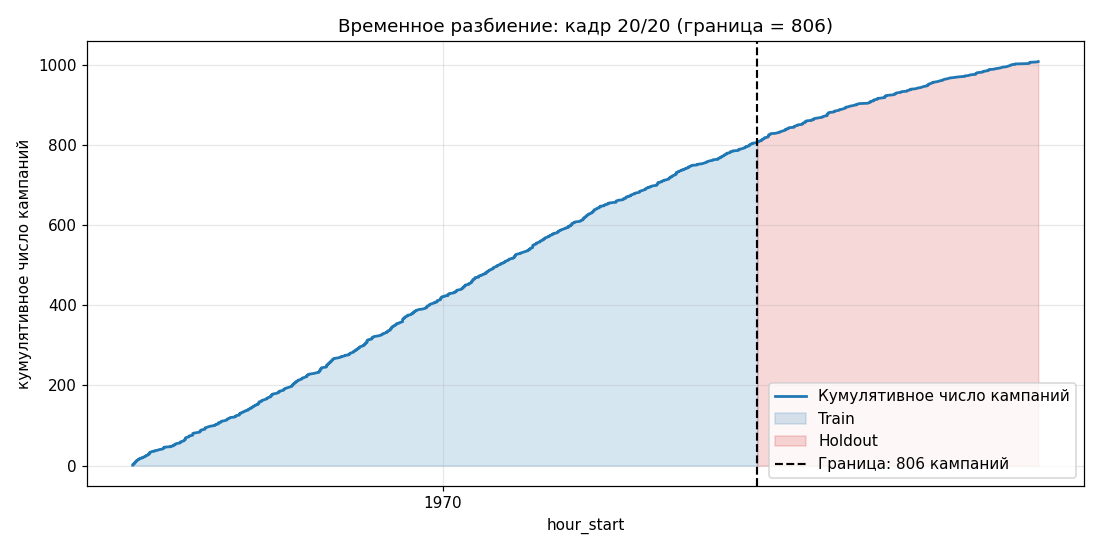

In [9]:
final_frame = OUT_DIR / f'fig_split_step_{N_FRAMES:03d}.png'
display(Image(filename=str(final_frame)))

### Результаты 

- Загружены данные, разбиение train/holdout
- Построена 39-мерная матрица leak-safe признаков.
- Последний график соответствует реальному временному разбиению